# Resumen de Funcionalidad y Resultados

Este notebook está diseñado para procesar y analizar datos textuales (reseñas de música) utilizando dos enfoques principales de NLP:

### 1. Análisis de Sentimiento (VADER)
- **Herramienta:** Utiliza el analizador `VADER` para determinar la polaridad de los textos.
- **Proceso:** Evalúa frases de ejemplo para mostrar cómo se calculan las puntuaciones de positividad, negatividad, neutralidad y el índice *compound* (combinado).
- **Resultado:** Demuestra que el modelo es sensible a la puntuación (signos de exclamación) y emoticonos, proporcionando una métrica cuantitativa del sentimiento.

### 2. Modelado de Temas (LDA)
- **Herramienta:** Utiliza la librería `gensim` y el algoritmo `Latent Dirichlet Allocation` (LDA).
- **Dataset:** Se carga un archivo CSV (`Music_Market.csv`) con 50,000 registros.
- **Preprocesamiento y Vectorización (BoW):**
  - **Limpieza de texto:** Conversión a minúsculas y eliminación de caracteres especiales.
  - **Tokenización y Stopwords:** División del texto en palabras y eliminación de términos comunes sin valor semántico.
  - **Lematización:** Reducción de las palabras a su raíz morfológica basándose en su etiqueta POS (parte del discurso) para normalizar el vocabulario.
  - **Vectorización (Bag of Words):** Se utiliza `CountVectorizer` para crear una representación de 'Bolsa de Palabras' (BoW), transformando los documentos en una matriz de conteo de términos necesaria para el modelo.
- **Proceso y Ponderación:**
  - Se entrena el modelo LDA para identificar 7 temas.
  - **Criterios de Ponderación:** El modelo asigna pesos a las palabras basándose en su probabilidad de pertenencia a un tema específico frente a su distribución en todo el corpus (frecuencia relativa), identificando los términos que mejor definen cada categoría.

### 3. Visualización y Resultado Final
- **Funcionalidad:** Define funciones para generar nubes de palabras (`WordCloud`) y mapas de árbol (`Treemap`).
- **Resultado Final:** Se consolida el peso de las palabras de todos los temas en una **Nube de Palabras ponderada**, permitiendo identificar visualmente los conceptos más relevantes y recurrentes en todo el corpus analizado.

In [ ]:
# @title
!pip install squarify
!pip install vaderSentiment
!pip install gensim
!pip install --upgrade numpy
!pip install --upgrade matplotlib seaborn scikit-learn gensim pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 72.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: Operation cancelled by user
^C


In [ ]:
from gensim.models.ldamulticore import LdaMulticore
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import seaborn as sns
import nltk
import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import gensim
from gensim import corpora
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
from nltk import pos_tag
import pandas as pd
import squarify
from sklearn.preprocessing import MinMaxScaler

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# ANÁLISIS DE SENTIMIENTO
  ## Implica clasificar el texto como positivo, negativo o neutro
# VADER (Valence Aware Dictionary for Sentiment Reasoning)
  ## Es una herramiento de análisis de sentimiento basada en un léxico y reglas, espcialmente afinada para los sentimientos en RRSS.
  ## Es sensible tanto a la polaridad como a la fuerza de la emoción del texto
  ## Escala de -4 a +4

In [ ]:
# Descargamos elléxico de VADER
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Inicializar el analizador de sentimiento de VADER
sid = SentimentIntensityAnalyzer()

In [ ]:
# Texto muestra
text = 'VADER is smart, handsome and funny!'

In [ ]:
# Obtener las puntuaciones de sentimiento
sentiment_scores = sid.polarity_scores(text)
print(sentiment_scores)
#

{'neg': 0.0, 'neu': 0.248, 'pos': 0.752, 'compound': 0.8439}


In [ ]:
# Las puntuaciones podrían ser diferentes
raw_text = "I'm not happy with this product!!! It broke after one use :("
sentiment_scores_raw = sid.polarity_scores(raw_text)
print(sentiment_scores_raw)
#

{'neg': 0.515, 'neu': 0.485, 'pos': 0.0, 'compound': -0.8616}


In [ ]:
# Otra variante de análisis pero ahora sin símbolo de exclamación ni emoji
cleaned_text = "I'm not happy with this product. It broke after one use."
sentiment_scores_clean = sid.polarity_scores(cleaned_text)
print(sentiment_scores_clean)
#

{'neg': 0.392, 'neu': 0.608, 'pos': 0.0, 'compound': -0.7002}


In [ ]:
## MODELADO DE TEMAS - TOPIC MODELING (MINERÍA DE TEXTO)
  ### ALGORITMO LDA (LATEN DIRICHLET ALLOCATION)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/NLP II - Silvia Ariza/Python/Music_Market.csv"

music_market = pd.read_csv(csv_path)

display(music_market.head())
music_market.shape

,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,verified_purchase,helpful_vote,...,product_type,average_rating,rating_number,price,store,categories,Cleaned Tokens,Lemmatized Tokens,Bigrams,Trigrams
0,0,5.0,Five Stars,LOVE IT!,B002MW50JA,B002MW50JA,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650777000,True,0,...,Television Soundtracks,4.6,186,19.610001,Yo Gabba Gabba! Format: Audio CD,"['CDs & Vinyl', 'Soundtracks', 'Television Sou...",['love'],['love'],[],[]
1,1,5.0,Five Stars,LOVE!!,B008XNPN0S,B008XNPN0S,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650764000,True,0,...,Children's Music,4.5,49,14.380000,Yo Gabba Gabba! Format: Audio CD,"['CDs & Vinyl', ""Children's Music""]",['love'],['love'],[],[]
2,2,3.0,Three Stars,Sad there is not the versions with the real/or...,B00IKM5N02,B00IKM5N02,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452649885000,True,0,...,Disney,4.6,5324,7.760000,Disney Karaoke Series Format: Audio CD,"['CDs & Vinyl', ""Children's Music"", 'Disney']","['sad', 'versions', 'realoriginal', 'artistsit...","['sad', 'version', 'realoriginal', 'artistsits...","[('sad', 'version'), ('version', 'realoriginal...","[('sad', 'version', 'realoriginal'), ('version..."
3,3,3.0,Disappointed,I have listen to The Broadway 1958 Flower Drum...,B00006JKCM,B00006JKCM,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,1164036864000,True,3,...,Musicals,4.8,45,NaN,"Oscar Hammerstein II (Composer), Richard ...","['CDs & Vinyl', 'Broadway & Vocalists', 'Music...","['listen', 'broadway', '1958', 'flower', 'drum...","['listen', 'broadway', '1958', 'flower', 'drum...","[('listen', 'broadway'), ('broadway', '1958'),...","[('listen', 'broadway', '1958'), ('broadway', ..."
4,4,5.0,Wonderful melding,Simply great album. One of the best. Marvelous...,B00013YRQY,B00013YRQY,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,1582090199946,False,0,...,Universal Music Group,5.0,7,NaN,Burt Bacharach Ron Isley&burt Bacharach Fo...,"['CDs & Vinyl', 'Universal Music Group']","['simply', 'great', 'album', 'one', 'best', 'm...","['simply', 'great', 'album', 'one', 'best', 'm...","[('simply', 'great'), ('great', 'album'), ('al...","[('simply', 'great', 'album'), ('great', 'albu..."


(50000, 21)

In [ ]:
documents = music_market["text"].dropna().astype(str).tolist()

documents[:5]

['LOVE IT!',
 'LOVE!!',
 'Sad there is not the versions with the real/original artists...Its OK',
 "I have listen to The Broadway 1958 Flower Drum soundtrack since I was a little girl. I loved it so much I had my dance teacher arrange a solo dance to the overature for me. A month ago I ordered the 1961 Film version expecting it to be equally beautifull. I couldn't believe my ears!!! It lacked so much depth that was contained in the 1958 version. Comparing the 2 Overatures the 1961 version seemed to skip right through it and it lacked the intence feelings the original 1958 version abtained.",
 'Simply great album. One of the best. Marvelous arangements!!!']

In [94]:
from numpy import vectorize
# Vectorizamos cada término del documento mediante gensim
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)
corpus = gensim.matutils.Sparse2Corpus(X, documents_columns=False)

# Se procesa el cuerpo pero no se imprime para evitar saturar el output
# for doc in corpus:
#   cleaned_doc = [(int(idx), int(count)) for idx, count in doc]

In [ ]:
# Creamos un objeto diccionario, cada palabra única tendrá un ID entero
feature_names = vectorizer.get_feature_names_out()
id2word = {i: word for i, word in enumerate(feature_names) }


In [ ]:
# Ahora entrenamos el modelo LDA, que supone:
  # Distribución de Temas: Aprender la distribución de los temas a través de los documentos
  # Distribución de Palabras: Aprender la distribución de palabras a través de los temas

# Necesitamos elegir
  # corpus: El de Gensim = Lista de Tuplas por cada documento
  # num_topics: Número de temas a generar
  # id2word: Diccionario de Gensim ue hemos creado con asignación de clave a cada término
  # passes: número de iteraciones sobre todo el corpus durante el entrenamiento (más mejor pero sin exagerar)

In [ ]:
# Entrenamiento
lda = LdaModel(corpus, num_topics=10, id2word=id2word, passes=50)

In [ ]:
# Extraemos los temas del modelo LDA entrenado, num_words = 10 implica que de cada tema sacará 10 términos fuertemente correlacionados con el contecto del corpus.
# La función devuelve una lista de tuplas, donde cada una contiene el índice del tema y una representación en formato texto del tema con sus palabras principales.

In [ ]:
# Muestra los temas
topics = lda.print_topics(num_words=6)
print('Topics')
for topic in topics:
      print(topic)


Topics
(0, '0.091*"the" + 0.054*"of" + 0.043*"and" + 0.036*"is" + 0.027*"in" + 0.018*"to"')
(1, '0.057*"cd" + 0.055*"it" + 0.052*"great" + 0.051*"this" + 0.040*"my" + 0.040*"love"')
(2, '0.030*"dave" + 0.016*"dan" + 0.015*"miles" + 0.011*"crap" + 0.009*"perry" + 0.009*"diana"')
(3, '0.021*"tom" + 0.019*"disks" + 0.018*"worship" + 0.014*"willie" + 0.014*"prog" + 0.013*"elvis"')
(4, '0.056*"her" + 0.051*"quot" + 0.050*"he" + 0.050*"his" + 0.043*"she" + 0.035*"voice"')
(5, '0.046*"the" + 0.044*"on" + 0.039*"and" + 0.021*"of" + 0.020*"in" + 0.016*"is"')
(6, '0.348*"34" + 0.035*"as" + 0.015*"fast" + 0.013*"bach" + 0.012*"conducting" + 0.012*"shipping"')
(7, '0.053*"the" + 0.033*"to" + 0.031*"and" + 0.027*"of" + 0.024*"this" + 0.024*"it"')
(8, '0.443*"br" + 0.017*"track" + 0.014*"you" + 0.012*"10" + 0.007*"love" + 0.007*"tracks"')
(9, '0.092*"the" + 0.032*"was" + 0.019*"is" + 0.017*"not" + 0.016*"sound" + 0.016*"but"')


In [ ]:
# Mal resultado puesto que no hemos quitado los stopwords
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    # Convertimos a lowercase
    text = text.lower()
    # Eliminamos caracteres especiales y puntuación
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    #Tokenizamos el texto
    tokens = word_tokenize(text)
    # Eliminamos las stop words
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [ ]:
def lemmatize_tokens(tokens):
    pos_tags = pos_tag(tokens)
    lemmatized_tokens = []
    for token, tag in pos_tags:
        pos = tag[0].lower()
        if pos in ['a', 'r', 'n', 'v']:
            lemmatized_tokens.append(lemmatizer.lemmatize(token, pos))
        else:
            lemmatized_tokens.append(lemmatizer.lemmatize(token))
    return lemmatized_tokens

In [95]:
cleaned_texts = []
# Iteramos sobre todos los documentos
for doc in documents:
    cl_text = clean_text(doc)
    lem_text = lemmatize_tokens(cl_text)
    cleaned_texts.append(lem_text)

print(f"Procesados {len(cleaned_texts)} documentos.")

Procesados 50000 documentos.


In [96]:
# Ahora corresponde la vectorización de documentos
vectorizer = CountVectorizer()
cleaned_texts_str = [str(doc) for doc in cleaned_texts]
X = vectorizer.fit_transform(cleaned_texts_str)
corpus = gensim.matutils.Sparse2Corpus(X, documents_columns=False)

# El corpus está listo para el modelo LDA (se omite el print masivo)

In [105]:
# Creamos un objeto diccionario, cada palabra única tendrá un ID entero
feature_names = vectorizer.get_feature_names_out()
id2word = {i: word for i, word in enumerate(feature_names) }
# Se omite la impresión de id2word para mantener el notebook limpio

In [ ]:
# Una vez limpio el corpus reentrenamos el modelo LDA
lda = LdaModel(corpus, num_topics=10, id2word=id2word, passes=50)

In [ ]:
# Muestra los temas
topics = lda.print_topics(num_words=10)
print('Topics')
for topic in topics:
      print(topic)

Topics
(0, '0.023*"song" + 0.022*"album" + 0.017*"cd" + 0.017*"one"')
(1, '0.086*"br" + 0.043*"track" + 0.033*"album" + 0.009*"record"')
(2, '0.133*"excellent" + 0.012*"bluegrass" + 0.008*"jerry" + 0.008*"jackson"')
(3, '0.067*"awesome" + 0.012*"perfect" + 0.010*"dylan" + 0.010*"pink"')
(4, '0.012*"maiden" + 0.010*"dan" + 0.009*"iron" + 0.008*"frame"')
(5, '0.072*"karaoke" + 0.057*"thanks" + 0.040*"machine" + 0.008*"disturb"')
(6, '0.068*"love" + 0.049*"great" + 0.048*"music" + 0.043*"cd"')
(7, '0.059*"product" + 0.025*"sleep" + 0.024*"sonata" + 0.019*"chopin"')
(8, '0.014*"gabba" + 0.013*"de" + 0.012*"la" + 0.010*"adele"')
(9, '0.014*"br" + 0.014*"record" + 0.014*"performance" + 0.012*"sound"')


In [ ]:
# Generamos las frecuencias de palabras para cada tema
# Extraemos los temas y sus palabras asociadas
topics = lda.show_topics(num_words=50, formatted=False)

def extract_word_frequencies(topics):
  word_freqs=[]
  for topic in topics:
    word_freq = {word: weight for word, weight in topic[1] }
    word_freqs.append(word_freq)
  return word_freqs

word_freqs = extract_word_frequencies(topics)

# Graficamos los Treemaps para cada tema
def plot_treemap(word_freq, topic_num):
  labels = list (word_freq.keys())
  sizes = list(word_freq.values())

  plt.figure(figsize=(12, 8))
  squarify.plot(sizes=sizes, label=labels, alpha=0.8) # Changed 'labels' to 'label'
  plt.title(f'Treemap for Topic {topic_num}')
  plt.axis('off')
  plt.show

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def preparar_frecuencias(elementos):
    """
    Convierte palabras, bigramas o trigramas en un diccionario:
    texto -> frecuencia

    Sirve para:
    - lista de palabras
    - set de palabras únicas
    - lista de tuplas tipo ('very', 'good')
    - Counter de palabras
    - Counter de tuplas
    """

    # Si ya es Counter, lo usamos directamente
    if isinstance(elementos, Counter):
        contador = elementos
    else:
        contador = Counter(elementos)

    frecuencias = {}

    for clave, freq in contador.items():

        # Si la clave es una tupla, por ejemplo ('very', 'good')
        if isinstance(clave, tuple):
            texto = " ".join(clave)

        # Si la clave ya es texto
        else:
            texto = str(clave)

        frecuencias[texto] = freq

    return frecuencias


def plot_wordcloud(freq_dict, title, max_words=100):
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=max_words
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

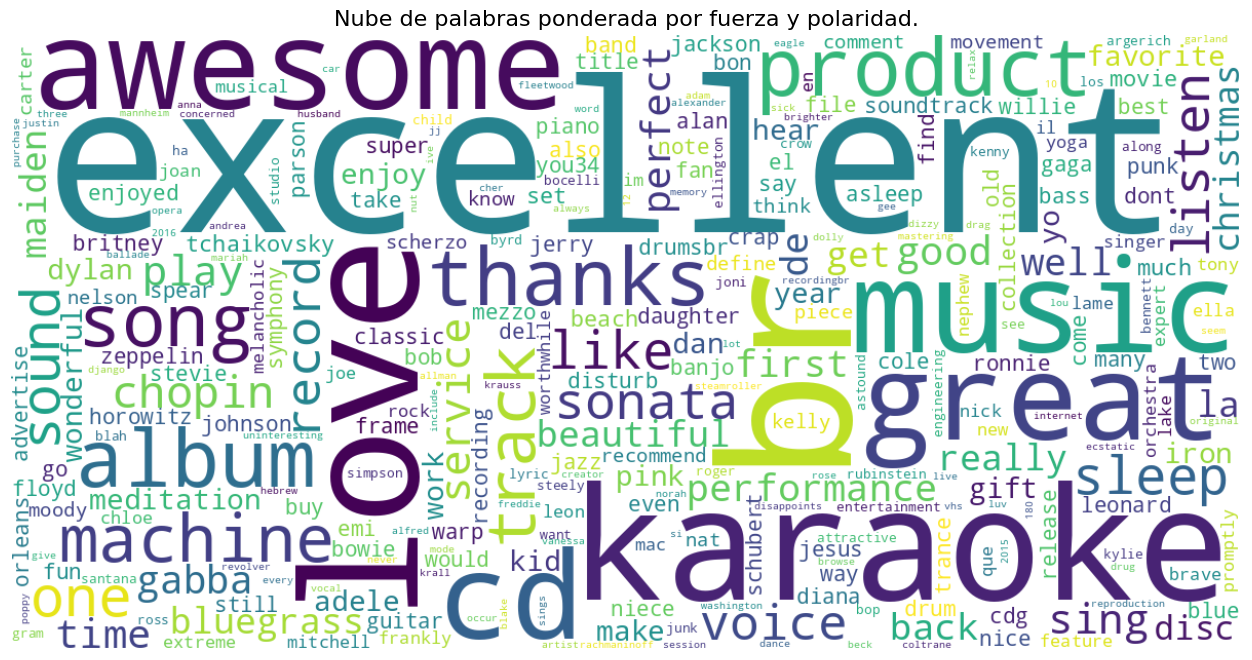

In [ ]:
combined_word_freq = {}
for topic_id, topic_content in topics:
    # Check if content is a string (formatted) or a list (unformatted)
    if isinstance(topic_content, str):
        for item in topic_content.split(' + '):
            weight_str, word_str = item.split('*', 1)
            word = word_str.strip('"')
            weight = float(weight_str)
            combined_word_freq[word] = combined_word_freq.get(word, 0) + weight
    else:
        # It's already a list of (word, weight) tuples
        for word, weight in topic_content:
            combined_word_freq[word] = combined_word_freq.get(word, 0) + float(weight)

plot_wordcloud(
    combined_word_freq,
    title='Nube de palabras ponderada por fuerza y polaridad.',
    max_words=300
)

# Fin del Análisis

In [101]:
# Celda eliminada

Config OK → minus5-xp/text_mining_amazon_music_transactions  branch: main


In [102]:
# Celda eliminada

Repositorio ya existe: https://github.com/minus5-xp/text_mining_amazon_music_transactions
Rama por defecto actual: main
Repositorio y rama 'main' listos.


In [103]:
# Celda eliminada

README.md y .gitignore actualizados.


In [104]:
# Celda eliminada


✓ Sincronización exitosa → https://github.com/minus5-xp/text_mining_amazon_music_transactions
